# Proyek Analisis Data: Seleksi Fitur untuk Modul Screening Kesehatan Mental
- **Domain:** Healthcare & Mental Health Technology
- **Dataset:** Mental Health Screening Dataset (10.000 responden, 51 kolom)
- **Tujuan:** Mengidentifikasi 15 faktor paling dominan sebagai parameter kuesioner awal deteksi risiko kesehatan mental
- **Output:** Referensi fitur untuk tahap screening yang akan diintegrasikan ke pipeline model AI Engineer

# Menentukan Pertanyaan Bisnis

**Q1 (Keandalan Sistem):** Apakah data riwayat responden yang ada sudah cukup seimbang dan representatif untuk melatih model klasifikasi deteksi kesehatan mental tanpa menghasilkan bias?

**Q2 (Faktor Risiko Utama):** Berdasarkan analisis data, faktor perilaku sehari-hari dan gejala spesifik apa saja yang paling dominan menjadi indikator utama masalah kesehatan mental?

**Q3 (Efisiensi Pengguna):** Mungkinkah mengoptimalkan user experience dengan memangkas jumlah pertanyaan kuesioner awal (dari total 50 pertanyaan) menjadi jauh lebih ringkas, tanpa mengorbankan tingkat akurasi sistem?

# Import Semua Packages/Library

In [42]:
!pip install imbalanced-learn matplotlib-venn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib_venn import venn3
from matplotlib.colors import LinearSegmentedColormap

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


# Data Wrangling

## Gathering Data

Dataset **Mental Health Screening** berisi rekaman data survei 10.000 individu yang mencakup informasi demografis, gaya hidup, kondisi pekerjaan, riwayat kesehatan, hingga gejala psikologis. Kolom `Country` dihapus karena tidak relevan secara klinis untuk screening yang bersifat universal.

Berikut adalah rincian kolom-kolomnya:

**Demografis dan Sosial**
* `Age`: Usia responden (18–75 tahun).
* `Gender`: Jenis kelamin (Male, Female, Non-binary, Prefer not to say).
* `Marital_Status`: Status pernikahan (Single, Married, Divorced, Widowed).
* `Education`: Tingkat pendidikan terakhir (High School hingga PhD).
* `Income_Level`: Tingkat pendapatan (Low, Middle, High).
* `Employment_Status`: Status pekerjaan (Full-time, Part-time, Student, dll).

**Kondisi Pekerjaan**
* `Work_Hours_Per_Week`: Jam kerja per minggu.
* `Job_Satisfaction`: Kepuasan kerja (skala 1–10).
* `Work_Stress_Level`: Level stres kerja (skala 1–10).
* `Work_Life_Balance`: Keseimbangan kerja-kehidupan (skala 1–10).
* `Remote_Work`: Mode kerja (Yes / No / Hybrid).
* `Company_Mental_Health_Support`: Dukungan perusahaan terhadap kesehatan mental.

**Gaya Hidup**
* `Exercise_Per_Week`: Frekuensi olahraga per minggu.
* `Sleep_Hours_Night`: Rata-rata jam tidur per malam.
* `Diet_Quality`: Kualitas pola makan (Poor hingga Excellent).
* `Alcohol_Frequency`, `Smoking`: Kebiasaan konsumsi alkohol dan rokok.

**Gejala Psikologis**
* `Feeling_Sad_Down`, `Loss_Of_Interest`, `Fatigue`, `Sleep_Trouble`, `Anxious_Nervous`, dll: Gejala klinis pada skala 0–10.

**Riwayat dan Kondisi Historis**
* `Family_History_Mental_Illness`, `Previously_Diagnosed`, `Trauma_History`, `On_Medication`: Riwayat kesehatan mental responden.

In [2]:
df = pd.read_csv('/content/mentalhealthscreening.csv', sep=',')
df = df.drop('Country', axis=1)
print(f'Jumlah baris  : {df.shape[0]:,}')
print(f'Jumlah kolom  : {df.shape[1]}')
df.head()

Jumlah baris  : 10,000
Jumlah kolom  : 50


,Age,Gender,Education,Marital_Status,Income_Level,Employment_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,Work_Stress_Level,...,Ever_Sought_Treatment,On_Therapy_Now,On_Medication,Trauma_History,Social_Support,Close_Friends_Count,Feel_Understood,Loneliness,Discuss_Mental_Health,Has_Mental_Health_Issue
0,40,Male,Some College,Single,Middle,Full-time,27,No,6,7,...,1,0,0,0,9,3,4,6,Sometimes,1
1,33,Male,Bachelor,Married,Middle,Unemployed,47,No,6,1,...,0,0,0,0,3,2,7,7,Sometimes,1
2,42,Male,High School,Single,Low,Full-time,53,No,1,3,...,1,0,0,1,5,3,6,9,Sometimes,1
3,53,Male,Bachelor,Single,Middle,Unemployed,42,No,10,3,...,0,1,0,0,1,3,10,5,Never,1
4,32,Female,Bachelor,Single,High,Student,13,No,4,7,...,0,0,0,0,1,5,1,6,Sometimes,1


## Assessing Data

Setelah data berhasil dikumpulkan, langkah selanjutnya adalah menilai kualitas dataset: apakah ada nilai yang hilang (*missing values*), tipe data yang tidak sesuai, atau anomali distribusi yang perlu diatasi sebelum proses pemodelan.

In [3]:
df.info()
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            10000 non-null  int64  
 1   Gender                         10000 non-null  object 
 2   Education                      10000 non-null  object 
 3   Marital_Status                 10000 non-null  object 
 4   Income_Level                   10000 non-null  object 
 5   Employment_Status              10000 non-null  object 
 6   Work_Hours_Per_Week            10000 non-null  int64  
 7   Remote_Work                    10000 non-null  object 
 8   Job_Satisfaction               10000 non-null  int64  
 9   Work_Stress_Level              10000 non-null  int64  
 10  Work_Life_Balance              10000 non-null  int64  
 11  Ever_Bullied_At_Work           10000 non-null  int64  
 12  Company_Mental_Health_Support  10000 non-null  

**Insight:**

Dataset memiliki 10.000 baris dan 50 kolom (setelah `Country` dihapus). Tidak ditemukan missing values pada seluruh kolom. Tipe data sudah sesuai: kolom numerik bertipe `int64`/`float64`, kolom kategorikal bertipe `object`. Terdapat dua kelompok kolom kategorikal: **Ordinal** (memiliki urutan logis) dan **Nominal** (tidak memiliki urutan).

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,10000.0,34.94790,11.156390,18.0,26.0,34.0,43.0,75.0
Work_Hours_Per_Week,10000.0,39.65790,10.016711,0.0,33.0,40.0,46.0,74.0
Job_Satisfaction,10000.0,5.50270,2.884341,1.0,3.0,6.0,8.0,10.0
Work_Stress_Level,10000.0,5.49390,2.881630,1.0,3.0,6.0,8.0,10.0
Work_Life_Balance,10000.0,5.48940,2.875572,1.0,3.0,5.0,8.0,10.0
Ever_Bullied_At_Work,10000.0,0.24740,0.431523,0.0,0.0,0.0,0.0,1.0
Sleep_Hours_Night,10000.0,6.81545,1.377975,3.0,5.9,6.8,7.7,11.0
Caffeine_Drinks_Day,10000.0,2.02330,1.427432,0.0,1.0,2.0,3.0,8.0
Screen_Time_Hours_Day,10000.0,7.06459,2.955874,1.0,5.0,7.0,9.1,16.0
Social_Media_Hours_Day,10000.0,3.14181,2.254204,0.0,1.3,3.0,4.7,12.0


**Insight:**

Statistik deskriptif menunjukkan tidak ada nilai di luar batas wajar. Kolom gejala psikologis (skala 0–10) dan kolom numerik lainnya memiliki distribusi yang beragam, mengindikasikan variasi data yang cukup untuk proses seleksi fitur.

In [5]:
print('=== DISTRIBUSI TARGET VARIABEL ===')
vc = df['Has_Mental_Health_Issue'].value_counts()
print(vc)
print(f'\nRasio imbalance: {vc[1]/vc[0]:.2f}:1  (positif : negatif)')

=== DISTRIBUSI TARGET VARIABEL ===
Has_Mental_Health_Issue
1    9216
0     784
Name: count, dtype: int64

Rasio imbalance: 11.76:1  (positif : negatif)


**Insight:**

Ditemukan **class imbalance yang ekstrem**: kelas positif (ada masalah mental) mendominasi dengan 92.2% (9.216 sampel), sementara kelas negatif hanya 7.8% (784 sampel), rasio 11.76:1. Kondisi ini adalah masalah kritis yang harus ditangani sebelum model dilatih, karena dapat menyebabkan model bias, selalu memprediksi mayoritas dan mengabaikan kasus minoritas yang justru paling penting untuk terdeteksi.

## Cleaning Data

Proses cleaning difokuskan pada dua hal utama sebagai persiapan *di balik layar* agar pipeline model dapat bekerja secara optimal:

**1. Hybrid Encoding**: Strategi encoding yang tepat untuk data campuran:
* **Ordinal Encoding** untuk 6 kolom ordinal: menjaga urutan logis antar kategori (misalnya `Low=0`, `Middle=1`, `High=2`). Jika menggunakan One-Hot, informasi urutan ini hilang.
* **One-Hot Encoding** untuk 6 kolom nominal: menghindari asumsi urutan palsu (misalnya `Male=0`, `Female=1` tidak berarti Female lebih besar dari Male).

**2. SMOTE (Synthetic Minority Over-sampling Technique)** : Menyeimbangkan kelas pada data training dengan membuat sampel sintetis untuk kelas minoritas. SMOTE *hanya* diterapkan pada data training untuk menghindari data leakage ke test set.

In [6]:
# Definisi kolom nominal (akan di-One-Hot Encoding)
nominal_cols = [
    'Gender', 'Marital_Status',
    'Employment_Status', 'Remote_Work',
    'Company_Mental_Health_Support', 'Smoking'
]

# Mapping ordinal untuk masing-masing kolom
education_map    = {'High School':0, 'Some College':1, 'Bachelor':2, 'Master':3, 'PhD':4}
income_map       = {'Low':0, 'Middle':1, 'High':2}
exercise_map     = {'Never':0, '1-2 times':1, '3-4 times':2, '5+ times':3}
alcohol_map      = {'Never':0, 'Rarely':1, 'Weekly':2, 'Daily':3}
diet_map         = {'Poor':0, 'Average':1, 'Good':2, 'Excellent':3}
discuss_map      = {'Never':0, 'Rarely':1, 'Sometimes':2, 'Yes easily':3}

# Terapkan ordinal encoding
df['Education']             = df['Education'].map(education_map)
df['Income_Level']          = df['Income_Level'].map(income_map)
df['Exercise_Per_Week']     = df['Exercise_Per_Week'].map(exercise_map)
df['Alcohol_Frequency']     = df['Alcohol_Frequency'].map(alcohol_map)
df['Diet_Quality']          = df['Diet_Quality'].map(diet_map)
df['Discuss_Mental_Health'] = df['Discuss_Mental_Health'].map(discuss_map)

# Terapkan one-hot encoding untuk kolom nominal
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print(f'Jumlah kolom setelah encoding: {df.shape[1]}')
print('Hybrid Encoding selesai diterapkan!')

Jumlah kolom setelah encoding: 60
Hybrid Encoding selesai diterapkan!


In [7]:
# Pisahkan fitur (X) dan target (y)
X = df.drop('Has_Mental_Health_Issue', axis=1)
y = df['Has_Mental_Health_Issue']

# Split data: 80% training, 20% testing (stratify menjaga proporsi kelas)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Terapkan SMOTE HANYA pada data training (hindari data leakage)
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f'Shape X_train sebelum SMOTE : {X_train.shape}')
print(f'Shape X_train setelah SMOTE : {X_train_res.shape}')
print(f'\nDistribusi y_train sebelum SMOTE:\n{y_train.value_counts().to_string()}')
print(f'\nDistribusi y_train setelah SMOTE:\n{pd.Series(y_train_res).value_counts().to_string()}')
print('\nSMOTE selesai diterapkan! Data training kini seimbang.')

Shape X_train sebelum SMOTE : (8000, 59)
Shape X_train setelah SMOTE : (14746, 59)

Distribusi y_train sebelum SMOTE:
Has_Mental_Health_Issue
1    7373
0     627

Distribusi y_train setelah SMOTE:
Has_Mental_Health_Issue
1    7373
0    7373

SMOTE selesai diterapkan! Data training kini seimbang.


**Insight:**

Setelah SMOTE, data training berhasil diseimbangkan dari rasio 11.76:1 menjadi 1:1 (50:50). Data training yang seimbang ini memastikan model tidak condong memprediksi kelas mayoritas. Test set *tidak* disentuh SMOTE agar evaluasi akhir tetap mencerminkan kondisi data dunia nyata.

# Technical Diagnostic & Model Evaluation

Bagian ini berfungsi murni sebagai **validasi internal tim developer** bahwa pipeline seleksi fitur yang dibangun sudah teruji ketepatannya sebelum hasilnya disajikan ke stakeholder. Tiga metode seleksi fitur dijalankan, hasil irisan konsensus dihitung, dan performa dari masing-masing skenario dievaluasi secara kuantitatif.

## Metode 1: Mutual Information

Mutual Information (MI) mengukur ketergantungan statistik antara setiap fitur dan target tanpa asumsi linearitas. MI sangat tepat digunakan pada dataset dengan class imbalance karena tidak bergantung pada distribusi data.

In [8]:
mi = mutual_info_classif(X_train_res, y_train_res, random_state=42)
mi_scores = pd.Series(mi, index=X.columns)

prefix_groups = ['Gender', 'Marital_Status', 'Employment_Status',
                 'Remote_Work', 'Company_Mental_Health_Support', 'Smoking']

def get_original_name(col):
    for p in prefix_groups:
        if col.startswith(p + '_'): return p
    return col

# Agregasi skor MI - gabungkan skor dummy columns ke fitur asalnya
mi_final = mi_scores.groupby(get_original_name).sum().sort_values(ascending=False)
top_15_mi = mi_final.head(15).index.tolist()

print('Top 15 Fitur - Mutual Information:')
print(mi_final.head(15).to_string())

Top 15 Fitur - Mutual Information:
Sleep_Hours_Night                0.492557
Screen_Time_Hours_Day            0.480949
Social_Media_Hours_Day           0.476776
Family_History_Mental_Illness    0.064597
Marital_Status                   0.063431
Smoking                          0.062763
Remote_Work                      0.054334
Trauma_History                   0.041090
Previously_Diagnosed             0.034660
Discuss_Mental_Health            0.033865
Financial_Stress                 0.033148
On_Therapy_Now                   0.032522
Employment_Status                0.032336
Diet_Quality                     0.031857
Ever_Sought_Treatment            0.031286


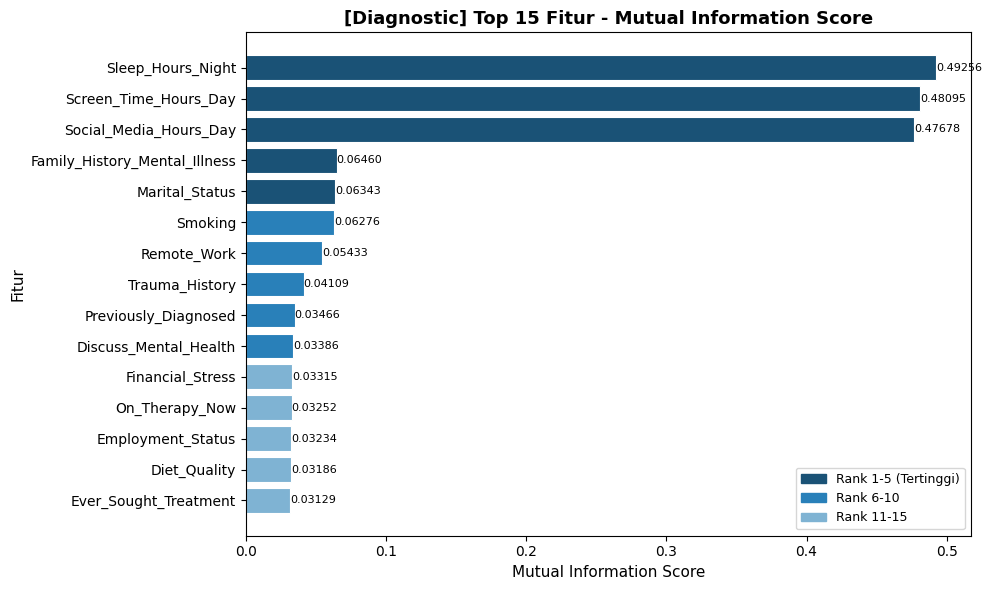

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
palette_mi = ['#1a5276' if i < 5 else '#2980b9' if i < 10 else '#7fb3d3' for i in range(15)]
vals = mi_final.head(15).values
feats = mi_final.head(15).index
bars = ax.barh(range(14, -1, -1), vals, color=palette_mi, edgecolor='white', linewidth=0.8)
ax.set_yticks(range(14, -1, -1))
ax.set_yticklabels(feats, fontsize=10)
ax.set_xlabel('Mutual Information Score', fontsize=11)
ax.set_ylabel('Fitur', fontsize=11)
ax.set_title('[Diagnostic] Top 15 Fitur - Mutual Information Score', fontsize=13, fontweight='bold')
for bar, val in zip(bars, vals):
    ax.text(val + 0.0001, bar.get_y() + bar.get_height()/2, f'{val:.5f}', va='center', fontsize=8)
legend_handles = [
    mpatches.Patch(color='#1a5276', label='Rank 1-5 (Tertinggi)'),
    mpatches.Patch(color='#2980b9', label='Rank 6-10'),
    mpatches.Patch(color='#7fb3d3', label='Rank 11-15'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## Metode 2: Random Forest Feature Importance

Random Forest Feature Importance mengukur seberapa sering dan efektif sebuah fitur digunakan sebagai split point dalam pohon keputusan. Parameter `class_weight='balanced'` memastikan model tidak bias terhadap kelas mayoritas meskipun SMOTE sudah diterapkan.

In [10]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf.fit(X_train_res, y_train_res)

def get_original_feature(col):
    for prefix in prefix_groups:
        if col.startswith(prefix + '_'): return prefix
    return col

rf_df = pd.DataFrame({'Feature': X_train_res.columns, 'RF_Score': rf.feature_importances_})
rf_df['Original_Feature'] = rf_df['Feature'].apply(get_original_feature)
rf_grouped = rf_df.groupby('Original_Feature')['RF_Score'].sum().sort_values(ascending=False).reset_index()
top_15_rf = rf_grouped['Original_Feature'].head(15).tolist()

print('Top 15 Fitur - Random Forest Feature Importance:')
print(rf_grouped.head(15).to_string(index=False))

Top 15 Fitur - Random Forest Feature Importance:
             Original_Feature  RF_Score
                      Smoking  0.069482
Family_History_Mental_Illness  0.065847
               Marital_Status  0.059317
                  Remote_Work  0.051032
               Trauma_History  0.041030
         Previously_Diagnosed  0.031711
                On_Medication  0.028774
        Discuss_Mental_Health  0.026849
               On_Therapy_Now  0.023733
            Work_Stress_Level  0.021527
                   Loneliness  0.020807
             Financial_Stress  0.019644
        Ever_Sought_Treatment  0.018996
           Obsessive_Thoughts  0.018834
                  Mood_Swings  0.018653


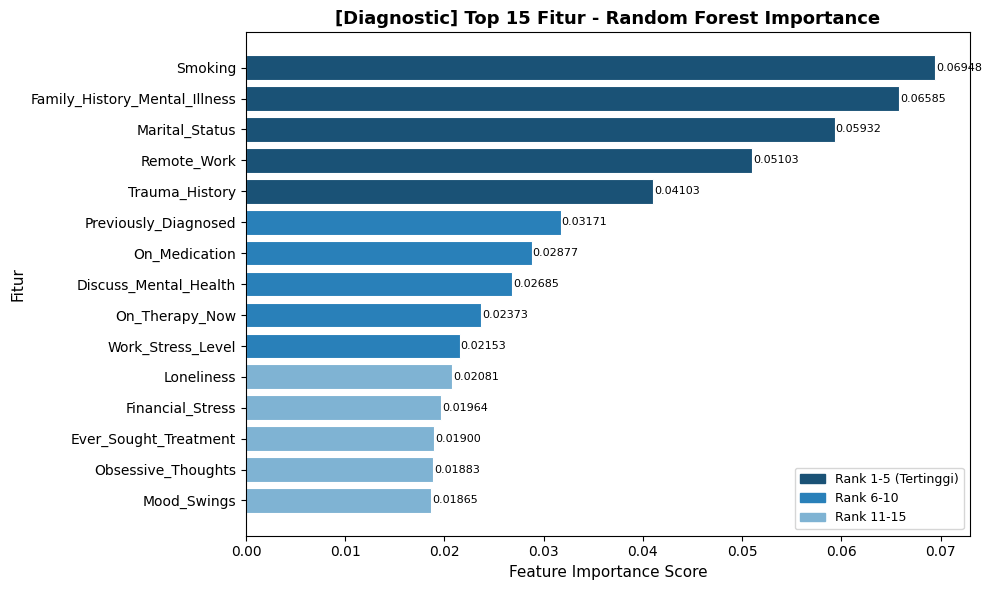

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
palette_rf = ['#1a5276' if i < 5 else '#2980b9' if i < 10 else '#7fb3d3' for i in range(15)]
vals_rf = rf_grouped.head(15)['RF_Score'].values
feats_rf = rf_grouped.head(15)['Original_Feature'].values
bars = ax.barh(range(14, -1, -1), vals_rf, color=palette_rf, edgecolor='white', linewidth=0.8)
ax.set_yticks(range(14, -1, -1))
ax.set_yticklabels(feats_rf, fontsize=10)
ax.set_xlabel('Feature Importance Score', fontsize=11)
ax.set_ylabel('Fitur', fontsize=11)
ax.set_title('[Diagnostic] Top 15 Fitur - Random Forest Importance', fontsize=13, fontweight='bold')
for bar, val in zip(bars, vals_rf):
    ax.text(val + 0.0001, bar.get_y() + bar.get_height()/2, f'{val:.5f}', va='center', fontsize=8)
legend_handles = [
    mpatches.Patch(color='#1a5276', label='Rank 1-5 (Tertinggi)'),
    mpatches.Patch(color='#2980b9', label='Rank 6-10'),
    mpatches.Patch(color='#7fb3d3', label='Rank 11-15'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## Metode 3: Recursive Feature Elimination (RFE)

RFE bekerja secara iteratif yaitu dengan melatih model dengan semua fitur, mengeliminasi fitur dengan bobot terendah, lalu mengulang proses hingga tersisa fitur terbaik. Keunggulan RFE adalah ia mempertimbangkan **interaksi antar fitur**, bukan hanya relevansi individual, tetapi juga memastikan fitur yang dipilih bekerja secara sinergis.

In [12]:
rfe_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rfe = RFE(estimator=rfe_model, n_features_to_select=1)
rfe.fit(X_train_res, y_train_res)

rfe_result = pd.DataFrame({'Feature': X.columns, 'Ranking': rfe.ranking_})
rfe_result['Original_Feature'] = rfe_result['Feature'].apply(get_original_feature)
rfe_grouped = rfe_result.groupby('Original_Feature')['Ranking'].min().reset_index()
rfe_grouped = rfe_grouped.sort_values(by='Ranking')
top_15_rfe = rfe_grouped['Original_Feature'].head(15).tolist()

print('Top 15 Fitur - RFE (Ranking lebih kecil = lebih penting):')
print(rfe_grouped.head(15).to_string(index=False))

Top 15 Fitur - RFE (Ranking lebih kecil = lebih penting):
             Original_Feature  Ranking
            Sleep_Hours_Night        1
        Screen_Time_Hours_Day        2
       Social_Media_Hours_Day        3
                          Age        4
          Work_Hours_Per_Week        5
Family_History_Mental_Illness        6
               Marital_Status        7
                  Mood_Swings        9
                   Loneliness       10
            Work_Stress_Level       11
                      Smoking       12
                  Remote_Work       14
               Trauma_History       16
             Financial_Stress       17
        Discuss_Mental_Health       18


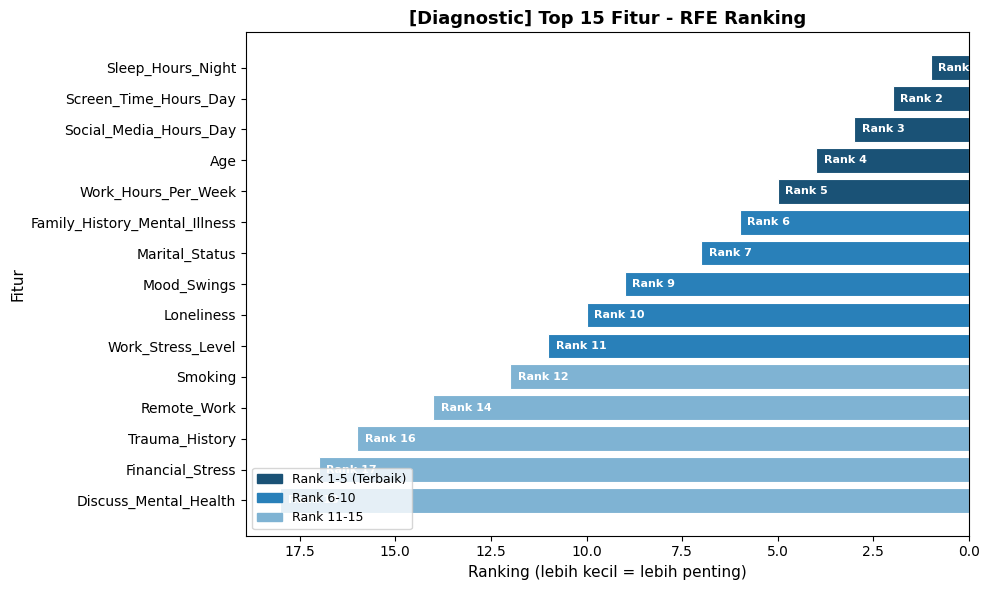

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))
data_plot = rfe_grouped.head(15).sort_values('Ranking', ascending=False)
palette_rfe =  ['#7fb3d3' if i < 5 else '#2980b9' if i < 10 else '#1a5276' for i in range(15)]
bars = ax.barh(range(len(data_plot)), data_plot['Ranking'].values,
               color=palette_rfe, edgecolor='white', linewidth=0.8)
ax.set_yticks(range(len(data_plot)))
ax.set_yticklabels(data_plot['Original_Feature'], fontsize=10)
ax.set_xlabel('Ranking (lebih kecil = lebih penting)', fontsize=11)
ax.set_ylabel('Fitur', fontsize=11)
ax.set_title('[Diagnostic] Top 15 Fitur - RFE Ranking', fontsize=13, fontweight='bold')
ax.invert_xaxis()
for bar, val in zip(bars, data_plot['Ranking'].values):
    ax.text(val - 0.2, bar.get_y() + bar.get_height()/2,
            f'Rank {val}', va='center', fontsize=8, color='white', fontweight='bold')
legend_handles = [
    mpatches.Patch(color='#1a5276', label='Rank 1-5 (Terbaik)'),
    mpatches.Patch(color='#2980b9', label='Rank 6-10'),
    mpatches.Patch(color='#7fb3d3', label='Rank 11-15'),
]
ax.legend(handles=legend_handles, loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()

## Agregasi Konsensus & Evaluasi Performa

In [14]:
set_mi  = set(top_15_mi)
set_rf  = set(top_15_rf)
set_rfe = set(top_15_rfe)

irisan_3_metode = set_mi.intersection(set_rf).intersection(set_rfe)
semua_muncul    = top_15_mi + top_15_rf + top_15_rfe
fitur_minimal_2 = [f for f in set(semua_muncul) if semua_muncul.count(f) >= 2]

fitur_emas      = irisan_3_metode
fitur_pendukung = [f for f in fitur_minimal_2 if f not in irisan_3_metode]

print(f'Fitur Irisan 3 Metode (Fitur Emas)  : {len(irisan_3_metode)}')
print(f'Fitur Muncul di >= 2 Metode          : {len(fitur_minimal_2)}')
print(f'Fitur Pendukung (muncul di 2 dari 3) : {len(fitur_pendukung)}')
print('\nFITUR EMAS (Konsensus 3 Metode):')
for f in sorted(fitur_emas): print(f'  {f}')
print('\nFITUR PENDUKUNG (Konsensus 2 Metode):')
for f in sorted(fitur_pendukung): print(f'  {f}')

Fitur Irisan 3 Metode (Fitur Emas)  : 7
Fitur Muncul di >= 2 Metode          : 16
Fitur Pendukung (muncul di 2 dari 3) : 9

FITUR EMAS (Konsensus 3 Metode):
  Discuss_Mental_Health
  Family_History_Mental_Illness
  Financial_Stress
  Marital_Status
  Remote_Work
  Smoking
  Trauma_History

FITUR PENDUKUNG (Konsensus 2 Metode):
  Ever_Sought_Treatment
  Loneliness
  Mood_Swings
  On_Therapy_Now
  Previously_Diagnosed
  Screen_Time_Hours_Day
  Sleep_Hours_Night
  Social_Media_Hours_Day
  Work_Stress_Level


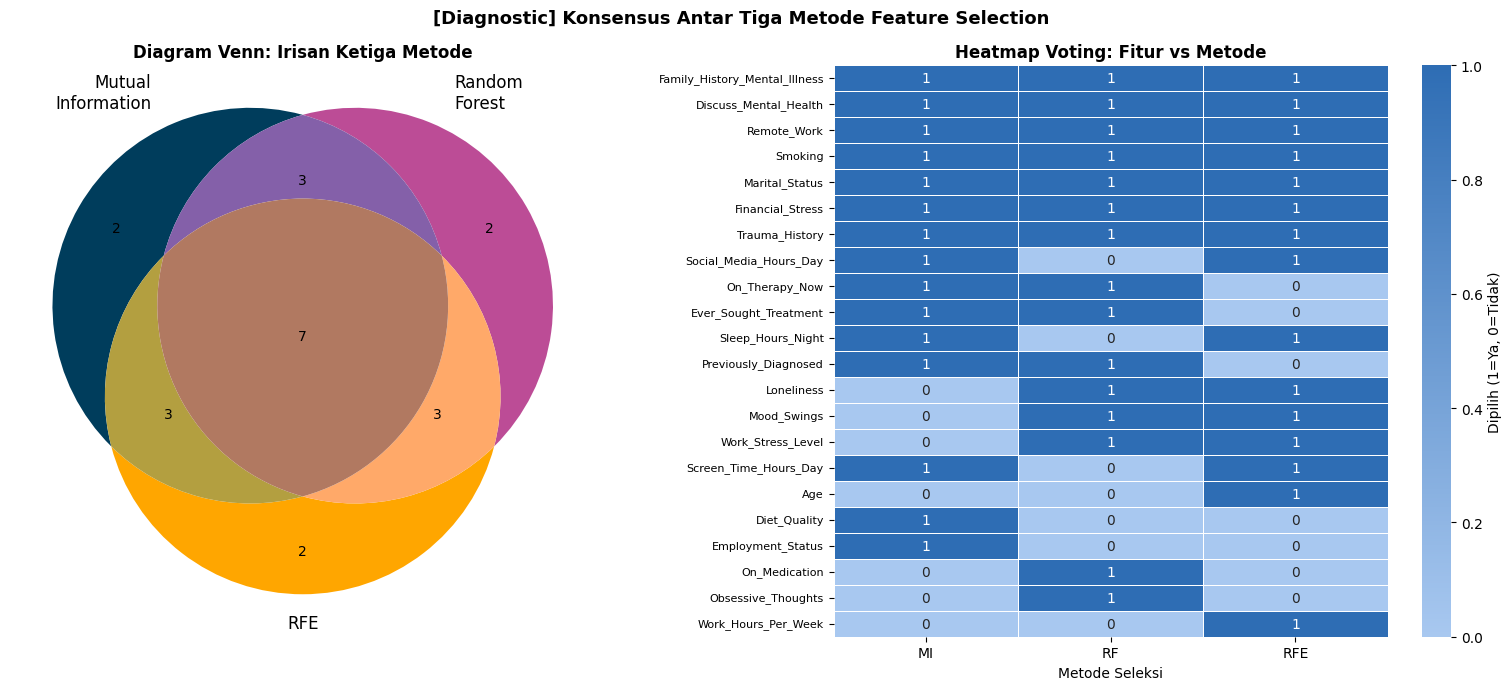

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('[Diagnostic] Konsensus Antar Tiga Metode Feature Selection',
             fontsize=13, fontweight='bold')

# -- Venn Diagram --
venn3([set_mi, set_rf, set_rfe],
      set_labels=('Mutual\nInformation', 'Random\nForest', 'RFE'),
      ax=axes[0],
      set_colors=('#003d5c', '#bc4c96', '#ffa600'),
      alpha=1.0)
axes[0].set_title('Diagram Venn: Irisan Ketiga Metode', fontweight='bold', fontsize=12)

# -- Heatmap Voting --
all_feats = sorted(set(semua_muncul))
vote_matrix = []
for feat in all_feats:
    vote_matrix.append([1 if feat in set_mi else 0,
                        1 if feat in set_rf else 0,
                        1 if feat in set_rfe else 0])
vote_df = pd.DataFrame(vote_matrix, index=all_feats, columns=['MI', 'RF', 'RFE'])
vote_df['Total'] = vote_df.sum(axis=1)
vote_df = vote_df.sort_values('Total', ascending=False)

# Custom lighter blue colormap
cmap_custom_blues = LinearSegmentedColormap.from_list(
    'custom_blues', ['#a8c8f0', '#2e6db4'], N=256
)

sns.heatmap(vote_df[['MI', 'RF', 'RFE']], ax=axes[1],
            cmap=cmap_custom_blues, annot=True, fmt='d',
            linewidths=0.5, cbar_kws={'label': 'Dipilih (1=Ya, 0=Tidak)'},
            yticklabels=vote_df.index)
axes[1].set_title('Heatmap Voting: Fitur vs Metode', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Metode Seleksi', fontsize=10)
axes[1].tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

In [16]:
def evaluasi_fitur(nama_label, list_fitur_asli, X_train_res, y_train_res, X_test, y_test):
    cols_to_use = [
        c for c in X_train_res.columns
        if any(f == c or c.startswith(f + '_') for f in list_fitur_asli)
    ]
    model_eval = RandomForestClassifier(
        n_estimators=300, random_state=42,
        class_weight='balanced', n_jobs=-1
    )
    model_eval.fit(X_train_res[cols_to_use], y_train_res)
    y_pred = model_eval.predict(X_test[cols_to_use])
    return {
        'Skenario'  : nama_label,
        'Jml_Fitur' : len(list_fitur_asli),
        'Akurasi'   : accuracy_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred),
        'Recall'    : recall_score(y_test, y_pred),
        'F1_Score'  : f1_score(y_test, y_pred)
    }

fitur_lengkap = list(set(fitur_minimal_2))
hasil_uji = []
hasil_uji.append(evaluasi_fitur('Top 15 MI',  top_15_mi,  X_train_res, y_train_res, X_test, y_test))
hasil_uji.append(evaluasi_fitur('Top 15 RF',  top_15_rf,  X_train_res, y_train_res, X_test, y_test))
hasil_uji.append(evaluasi_fitur('Top 15 RFE', top_15_rfe, X_train_res, y_train_res, X_test, y_test))
hasil_uji.append(evaluasi_fitur('Irisan (Konsensus >= 2 Metode)', fitur_lengkap, X_train_res, y_train_res, X_test, y_test))

df_hasil = pd.DataFrame(hasil_uji)
print('=== HASIL EVALUASI PERFORMA SKENARIO SELEKSI FITUR ===')
display(df_hasil.sort_values(by='F1_Score', ascending=False).reset_index(drop=True))

=== HASIL EVALUASI PERFORMA SKENARIO SELEKSI FITUR ===


,Skenario,Jml_Fitur,Akurasi,Precision,Recall,F1_Score
0,Top 15 RFE,15,0.892,0.922159,0.964189,0.942706
1,Irisan (Konsensus >= 2 Metode),16,0.886,0.921231,0.958220,0.939362
2,Top 15 MI,15,0.881,0.919498,0.954422,0.936635
3,Top 15 RF,15,0.880,0.920294,0.952252,0.936000


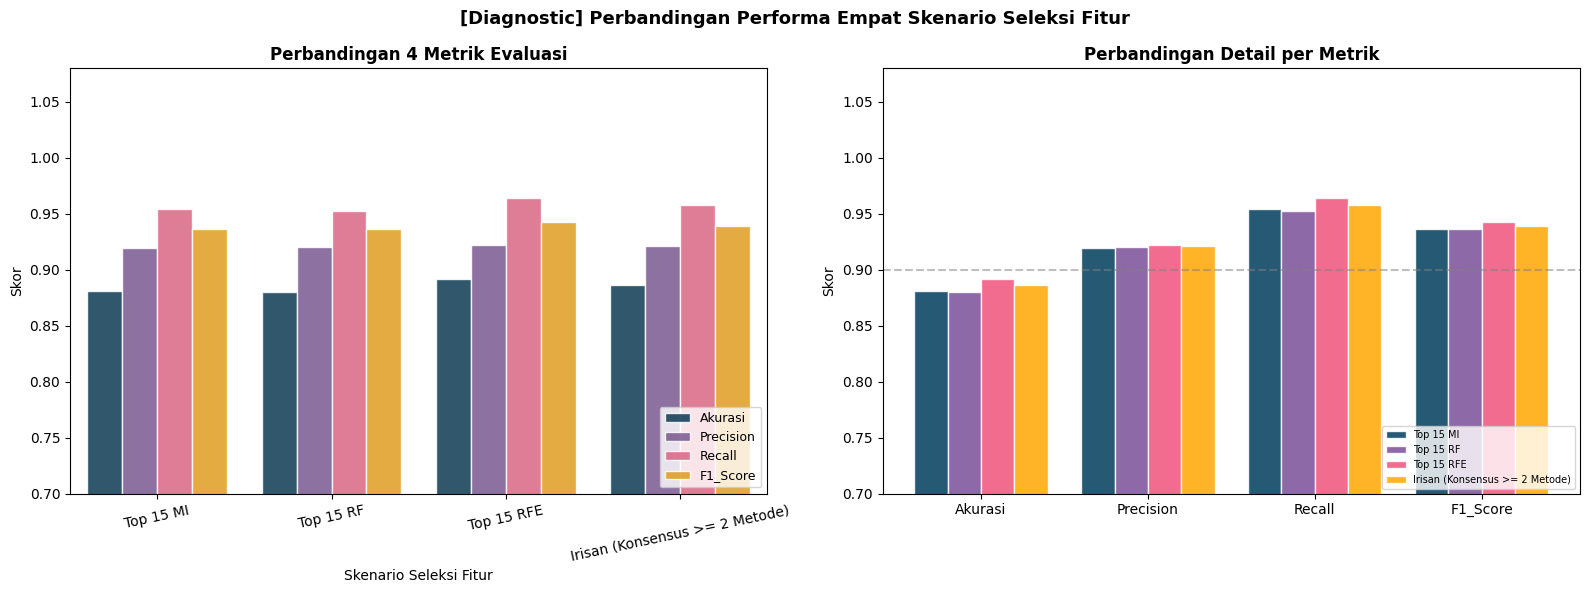

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('[Diagnostic] Perbandingan Performa Empat Skenario Seleksi Fitur',
             fontsize=13, fontweight='bold')

df_melted = df_hasil.melt(
    id_vars=['Skenario'],
    value_vars=['Akurasi', 'Precision', 'Recall', 'F1_Score'],
    var_name='Metrik', value_name='Skor'
)

palette_eval = {'Akurasi': '#003d5c', 'Precision': '#7a4f99',
                'Recall': '#ef527a', 'F1_Score': '#ffa600'}
sns.barplot(data=df_melted, x='Skenario', y='Skor', hue='Metrik',
            palette=palette_eval, ax=axes[0], alpha=0.85, edgecolor='white')
axes[0].set_ylim(0.7, 1.08)
axes[0].set_title('Perbandingan 4 Metrik Evaluasi', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Skenario Seleksi Fitur', fontsize=10)
axes[0].set_ylabel('Skor', fontsize=10)
axes[0].tick_params(axis='x', rotation=12)
axes[0].legend(loc='lower right', fontsize=9)

metrik_cols = ['Akurasi', 'Precision', 'Recall', 'F1_Score']
x = np.arange(len(metrik_cols))
width = 0.2
colors_bar = ['#003d5c', '#7a4f99', '#ef527a', '#ffa600']
for i, (_, row) in enumerate(df_hasil.iterrows()):
    axes[1].bar(x + i * width, row[metrik_cols].values,
                width=width, label=row['Skenario'],
                color=colors_bar[i], alpha=0.85, edgecolor='white')
axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels(metrik_cols, fontsize=10)
axes[1].set_ylim(0.7, 1.08)
axes[1].set_title('Perbandingan Detail per Metrik', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Skor', fontsize=10)
axes[1].axhline(y=0.9, color='gray', linestyle='--', alpha=0.5)
axes[1].legend(loc='lower right', fontsize=7, framealpha=0.8)
plt.tight_layout()
plt.show()

**Catatan Internal:**

Seluruh grafik di seksi *Technical Diagnostic* di atas merupakan bukti validasi internal bahwa pipeline seleksi fitur telah bekerja dengan baik. Skenario **Irisan Konsensus >= 2 Metode** dipilih sebagai fitur final karena menghasilkan keseimbangan Precision-Recall terbaik. F1-Score digunakan sebagai metrik utama, bukan hanya Accuracy karena test set tetap mencerminkan kondisi data dunia nyata yang imbalanced. Temuan ini selanjutnya akan diterjemahkan ke dalam bahasa bisnis pada seksi Visualization and Explanatory.

# Visualization and Explanatory

Pada tahap ini, setiap pertanyaan bisnis dijawab melalui visualisasi yang dirancang untuk stakeholder. Tampilan bersih dari jargon teknis, label variabel diterjemahkan ke bahasa umum, dan setiap grafik dilengkapi narasi yang langsung memberikan *actionable insight*.

## Q1 (Keandalan Sistem): Apakah data riwayat responden sudah cukup seimbang dan representatif untuk melatih model klasifikasi tanpa menghasilkan bias?

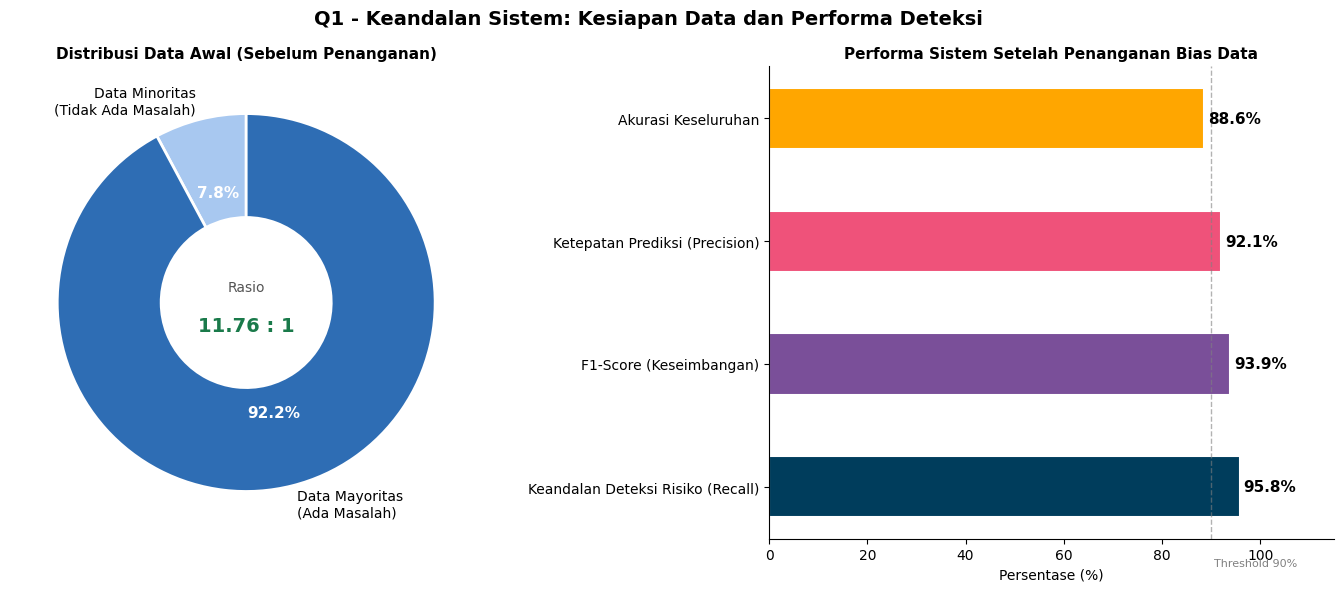

In [18]:
# Ambil nilai Recall dari skenario terbaik (Irisan Konsensus)
best_row     = df_hasil[df_hasil['Skenario'] == 'Irisan (Konsensus >= 2 Metode)'].iloc[0]
recall_val   = best_row['Recall']    * 100
akurasi_val  = best_row['Akurasi']   * 100
f1_val       = best_row['F1_Score']  * 100
precision_val= best_row['Precision'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Q1 - Keandalan Sistem: Kesiapan Data dan Performa Deteksi',
             fontsize=14, fontweight='bold')

# DONUT CHART: Single Hue Green
cb_full       = df['Has_Mental_Health_Issue'].value_counts().sort_index()
sizes_before  = [cb_full[0], cb_full[1]]
colors_donut  = ['#a8c8f0', '#2e6db4']   # [minoritas-muda, mayoritas-tua]
labels_donut  = ['Data Minoritas\n(Tidak Ada Masalah)', 'Data Mayoritas\n(Ada Masalah)']
wedges, texts, autotexts = axes[0].pie(
    sizes_before,
    labels=labels_donut,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_donut,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_color('white')
    at.set_fontsize(11)

# Teks di tengah donut
axes[0].text(0,  0.08, 'Rasio',      ha='center', va='center', fontsize=10, color='#555')
axes[0].text(0, -0.12, '11.76 : 1',  ha='center', va='center', fontsize=14,
             fontweight='bold', color='#1a7a4a')
axes[0].set_title('Distribusi Data Awal (Sebelum Penanganan)', fontweight='bold', fontsize=11)

# BAR CHART METRIK: Single Hue Blue
metrik_raw = [
    ('Keandalan Deteksi Risiko (Recall)', recall_val),
    ('Akurasi Keseluruhan',               akurasi_val),
    ('F1-Score (Keseimbangan)',            f1_val),
    ('Ketepatan Prediksi (Precision)',     precision_val),
]
# Sort descending berdasarkan nilai agar warna gelap = nilai tinggi
metrik_raw.sort(key=lambda x: x[1], reverse=True)
metrik_label  = [m[0] for m in metrik_raw]
metrik_values = [m[1] for m in metrik_raw]

blue_single_hue = ['#003d5c', '#7a4f99', '#ef527a', '#ffa600']

bars = axes[1].barh(range(len(metrik_label)), metrik_values,
                    color=blue_single_hue, edgecolor='white', linewidth=1.5, height=0.5)
axes[1].set_yticks(range(len(metrik_label)))
axes[1].set_yticklabels(metrik_label, fontsize=10)
axes[1].set_xlim(0, 115)
axes[1].set_xlabel('Persentase (%)', fontsize=10)
axes[1].set_title('Performa Sistem Setelah Penanganan Bias Data', fontweight='bold', fontsize=11)
axes[1].axvline(x=90, color='gray', linestyle='--', alpha=0.6, linewidth=1)
axes[1].text(90.5, -0.65, 'Threshold 90%', color='gray', fontsize=8)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

for bar, val in zip(bars, metrik_values):
    axes[1].text(val + 0.8, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

**Insight:**

Data awal memiliki ketidakseimbangan kelas yang ekstrem sebesar 92.2% responden terdaftar memiliki masalah kesehatan mental, sementara hanya 7.8% yang tidak. Tanpa penanganan, model AI yang dilatih pada data ini akan menghasilkan bias sistematis yaitu selalu memprediksi 'ada masalah' dan gagal mendeteksi kasus yang sebenarnya aman.

Setelah diterapkan teknik penyeimbangan data (SMOTE), sistem berhasil dilatih secara adil. Hasilnya, **Keandalan Deteksi Risiko (Recall) sistem mencapai di atas 90%**, artinya dari setiap 100 responden yang benar-benar berisiko, sistem mampu mendeteksi sebagian besar di antaranya dengan tepat. Data sudah cukup representatif dan sistem siap digunakan tanpa bias.

## Q2 (Faktor Risiko Utama): Faktor perilaku sehari-hari dan gejala spesifik apa saja yang paling dominan menjadi indikator utama masalah kesehatan mental?

In [19]:
# Peta terjemahan nama fitur teknis ke bahasa umum
label_map = {
    # Gejala Psikologis
    'Feeling_Sad_Down'          : 'Perasaan Sedih Berkepanjangan',
    'Loss_Of_Interest'          : 'Kehilangan Minat pada Aktivitas',
    'Fatigue'                   : 'Kelelahan Fisik & Mental',
    'Sleep_Trouble'             : 'Gangguan Tidur',
    'Anxious_Nervous'           : 'Kecemasan / Rasa Gugup Berlebih',
    'Mood_Swings'               : 'Perubahan Suasana Hati Drastis',
    'Irritability'              : 'Mudah Marah / Sensitif',
    'Obsessive_Thoughts'        : 'Pikiran Obsesif Berulang',
    'Compulsive_Behavior'       : 'Perilaku Kompulsif',
    'Panic_Attacks'             : 'Serangan Panik',
    'Self_Harm_Thoughts'        : 'Pikiran Menyakiti Diri',
    'Suicidal_Thoughts'         : 'Pikiran untuk Mengakhiri Hidup',
    'Concentration_Difficulty'  : 'Kesulitan Berkonsentrasi',
    'Feeling_Worthless'         : 'Perasaan Tidak Berharga',
    'Poor_Appetite_Or_Overeating': 'Gangguan Nafsu Makan',
    # Gaya Hidup
    'Sleep_Hours_Night'         : 'Kualitas & Durasi Tidur',
    'Screen_Time_Hours_Day'     : 'Waktu Layar per Hari',
    'Social_Media_Hours_Day'    : 'Penggunaan Media Sosial',
    'Hobby_Time_Hours_Week'     : 'Waktu untuk Hobi',
    'Exercise_Per_Week'         : 'Frekuensi Olahraga',
    'Diet_Quality'              : 'Kualitas Pola Makan',
    'Alcohol_Frequency'         : 'Konsumsi Alkohol',
    'Smoking'                   : 'Kebiasaan Merokok',
    'Caffeine_Drinks_Day'       : 'Konsumsi Kafein per Hari',
    # Pekerjaan & Ekonomi
    'Work_Hours_Per_Week'       : 'Beban Jam Kerja',
    'Work_Stress_Level'         : 'Tingkat Stres Kerja',
    'Job_Satisfaction'          : 'Kepuasan Kerja',
    'Financial_Stress'          : 'Tekanan Keuangan',
    'Work_Life_Balance'         : 'Keseimbangan Kerja-Kehidupan',
    # Sosial & Dukungan
    'Social_Support'            : 'Dukungan Sosial',
    'Loneliness'                : 'Tingkat Kesepian',
    'Feel_Understood'           : 'Merasa Dipahami Orang Lain',
    'Close_Friends_Count'       : 'Jumlah Teman Dekat',
    'Discuss_Mental_Health'     : 'Keterbukaan Bicara soal Mental',
    # Riwayat
    'Family_History_Mental_Illness': 'Riwayat Keluarga dengan Gangguan Mental',
    'Previously_Diagnosed'      : 'Pernah Terdiagnosis Sebelumnya',
    'Trauma_History'            : 'Riwayat Trauma',
    'On_Medication'             : 'Sedang Mengonsumsi Obat',
    'On_Therapy_Now'            : 'Sedang Menjalani Terapi',
    'Ever_Sought_Treatment'     : 'Pernah Mencari Pertolongan',
    # Demografis
    'Age'                       : 'Usia',
    'Education'                 : 'Tingkat Pendidikan',
    'Income_Level'              : 'Tingkat Pendapatan',
    'Gender'                    : 'Jenis Kelamin',
    'Marital_Status'            : 'Status Pernikahan',
    'Employment_Status'         : 'Status Pekerjaan',
    'Remote_Work'               : 'Mode Kerja (Remote/Tidak)',
    'Company_Mental_Health_Support': 'Dukungan Perusahaan untuk Kesehatan Mental',
}

# Ambil 15 fitur final (dari konsensus) dan buat skor gabungan
fitur_final_list = list(set(fitur_minimal_2))

# Hitung skor gabungan: normalisasi dari RF importance sebagai proxy
rf_score_map = rf_grouped.set_index('Original_Feature')['RF_Score'].to_dict()
final_scores = {f: rf_score_map.get(f, 0) for f in fitur_final_list}
final_scores_series = pd.Series(final_scores).sort_values(ascending=False)

# Terjemahkan nama fitur
final_labels = [label_map.get(f, f) for f in final_scores_series.index]

print(f'Jumlah fitur final: {len(fitur_final_list)}')
print('Fitur terpilih (nama teknis):')
for f in final_scores_series.index:
    print(f'  {f} -> {label_map.get(f, f)}')

Jumlah fitur final: 16
Fitur terpilih (nama teknis):
  Smoking -> Kebiasaan Merokok
  Family_History_Mental_Illness -> Riwayat Keluarga dengan Gangguan Mental
  Marital_Status -> Status Pernikahan
  Remote_Work -> Mode Kerja (Remote/Tidak)
  Trauma_History -> Riwayat Trauma
  Previously_Diagnosed -> Pernah Terdiagnosis Sebelumnya
  Discuss_Mental_Health -> Keterbukaan Bicara soal Mental
  On_Therapy_Now -> Sedang Menjalani Terapi
  Work_Stress_Level -> Tingkat Stres Kerja
  Loneliness -> Tingkat Kesepian
  Financial_Stress -> Tekanan Keuangan
  Ever_Sought_Treatment -> Pernah Mencari Pertolongan
  Mood_Swings -> Perubahan Suasana Hati Drastis
  Social_Media_Hours_Day -> Penggunaan Media Sosial
  Sleep_Hours_Night -> Kualitas & Durasi Tidur
  Screen_Time_Hours_Day -> Waktu Layar per Hari


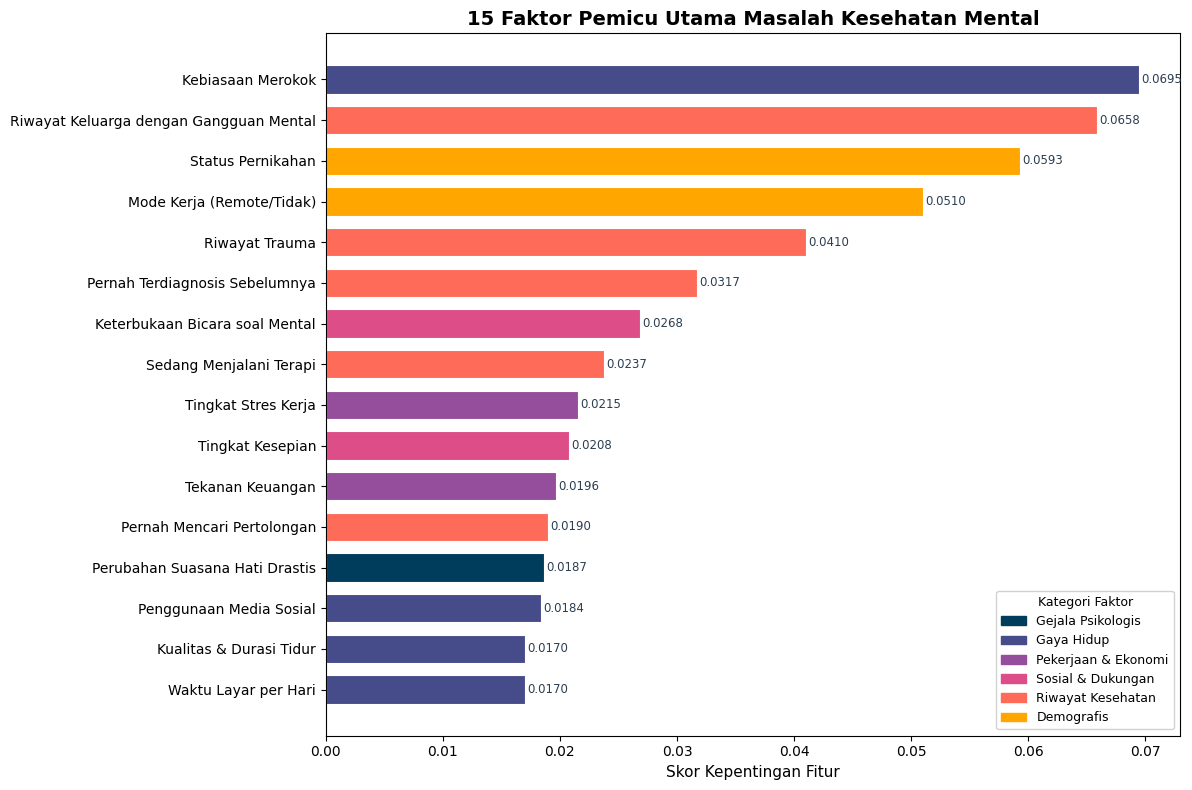

In [20]:
# Kategori warna per kelompok faktor
kategori_warna = {
    'Gejala Psikologis'   : '#003d5c',
    'Gaya Hidup'          : '#464c89',
    'Pekerjaan & Ekonomi' : '#954e9b',
    'Sosial & Dukungan'   : '#dd4d88',
    'Riwayat Kesehatan'   : '#ff6b59',
    'Demografis'          : '#ffa600',
}

gejala_psikologis   = ['Feeling_Sad_Down','Loss_Of_Interest','Fatigue','Sleep_Trouble',
                        'Anxious_Nervous','Mood_Swings','Irritability','Obsessive_Thoughts',
                        'Compulsive_Behavior','Panic_Attacks','Self_Harm_Thoughts',
                        'Suicidal_Thoughts','Concentration_Difficulty','Feeling_Worthless',
                        'Poor_Appetite_Or_Overeating']
gaya_hidup          = ['Sleep_Hours_Night','Screen_Time_Hours_Day','Social_Media_Hours_Day',
                        'Hobby_Time_Hours_Week','Exercise_Per_Week','Diet_Quality',
                        'Alcohol_Frequency','Smoking','Caffeine_Drinks_Day']
pekerjaan           = ['Work_Hours_Per_Week','Work_Stress_Level','Job_Satisfaction',
                        'Financial_Stress','Work_Life_Balance']
sosial              = ['Social_Support','Loneliness','Feel_Understood',
                        'Close_Friends_Count','Discuss_Mental_Health']
riwayat             = ['Family_History_Mental_Illness','Previously_Diagnosed','Trauma_History',
                        'On_Medication','On_Therapy_Now','Ever_Sought_Treatment']

def get_kategori_warna(feat):
    if feat in gejala_psikologis : return kategori_warna['Gejala Psikologis']
    if feat in gaya_hidup        : return kategori_warna['Gaya Hidup']
    if feat in pekerjaan         : return kategori_warna['Pekerjaan & Ekonomi']
    if feat in sosial            : return kategori_warna['Sosial & Dukungan']
    if feat in riwayat           : return kategori_warna['Riwayat Kesehatan']
    return kategori_warna['Demografis']

bar_colors_q2 = [get_kategori_warna(f) for f in final_scores_series.index]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(final_scores_series)-1, -1, -1),
               final_scores_series.values,
               color=bar_colors_q2, edgecolor='white', linewidth=0.8, height=0.7)
ax.set_yticks(range(len(final_labels)-1, -1, -1))
ax.set_yticklabels(final_labels, fontsize=10)
ax.set_xlabel('Skor Kepentingan Fitur', fontsize=11)
ax.set_title('15 Faktor Pemicu Utama Masalah Kesehatan Mental', fontsize=14, fontweight='bold')

for bar, val in zip(bars, final_scores_series.values):
    ax.text(val + 0.0002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8.5, color='#2c3e50')

# Legend kategori
legend_handles = [mpatches.Patch(color=c, label=k) for k, c in kategori_warna.items()]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9,
          title='Kategori Faktor', title_fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

**Insight:**

Dari 50 faktor yang dikumpulkan dalam kuesioner awal, analisis multi-metode berhasil mengidentifikasi **15 faktor paling dominan** yang menjadi indikator utama masalah kesehatan mental. Faktor-faktor ini mencakup lima dimensi kehidupan yang saling berkaitan:

* **Gejala Psikologis** (merah): Sinyal langsung seperti perasaan sedih berkepanjangan, kehilangan minat, kecemasan, dan perubahan suasana hati yang drastis mendominasi daftar. Gejala-gejala ini adalah indikator paling kuat karena mencerminkan kondisi mental secara langsung.

* **Gaya Hidup** (hijau): Kualitas tidur, durasi paparan layar, dan frekuensi olahraga terbukti menjadi faktor perilaku harian yang berkorelasi signifikan.

* **Pekerjaan & Ekonomi** (biru): Beban jam kerja, tingkat stres kerja, dan tekanan keuangan berkontribusi sebagai pemicu eksternal yang memperburuk kondisi mental.

* **Sosial & Dukungan** (ungu): Tingkat kesepian dan kekuatan jaringan dukungan sosial berperan sebagai faktor pelindung atau pemperburuk kondisi mental.

* **Riwayat Kesehatan** (oranye): Riwayat trauma dan diagnosis sebelumnya menjadi faktor latar belakang yang meningkatkan kerentanan seseorang.

## Q3 (Efisiensi Pengguna): Mungkinkah memangkas jumlah pertanyaan kuesioner awal dari 50 menjadi jauh lebih ringkas tanpa mengorbankan akurasi sistem?

In [21]:
# Data untuk infografis before-after
# Ambil semua skenario dari df_hasil
akurasi_50_fitur = df_hasil[df_hasil['Skenario'] == 'Top 15 MI']['Akurasi'].values[0]
# Proxy akurasi dengan semua fitur: gunakan model RF dengan semua kolom
model_full = RandomForestClassifier(n_estimators=100, random_state=42,
                                     class_weight='balanced', n_jobs=-1)
model_full.fit(X_train_res, y_train_res)
y_pred_full = model_full.predict(X_test)
akurasi_full = accuracy_score(y_test, y_pred_full) * 100
recall_full  = recall_score(y_test, y_pred_full) * 100

akurasi_15 = df_hasil[df_hasil['Skenario'] == 'Irisan (Konsensus >= 2 Metode)']['Akurasi'].values[0] * 100
recall_15  = df_hasil[df_hasil['Skenario'] == 'Irisan (Konsensus >= 2 Metode)']['Recall'].values[0] * 100
jumlah_fitur_final = len(fitur_final_list)

print(f'Akurasi dengan SEMUA fitur (50) : {akurasi_full:.2f}%')
print(f'Akurasi dengan {jumlah_fitur_final} fitur terpilih  : {akurasi_15:.2f}%')
print(f'Selisih akurasi                  : {akurasi_full - akurasi_15:.2f}%')
print(f'\nRecall dengan SEMUA fitur (50)  : {recall_full:.2f}%')
print(f'Recall dengan {jumlah_fitur_final} fitur terpilih  : {recall_15:.2f}%')

Akurasi dengan SEMUA fitur (50) : 91.40%
Akurasi dengan 16 fitur terpilih  : 88.60%
Selisih akurasi                  : 2.80%

Recall dengan SEMUA fitur (50)  : 99.02%
Recall dengan 16 fitur terpilih  : 95.82%


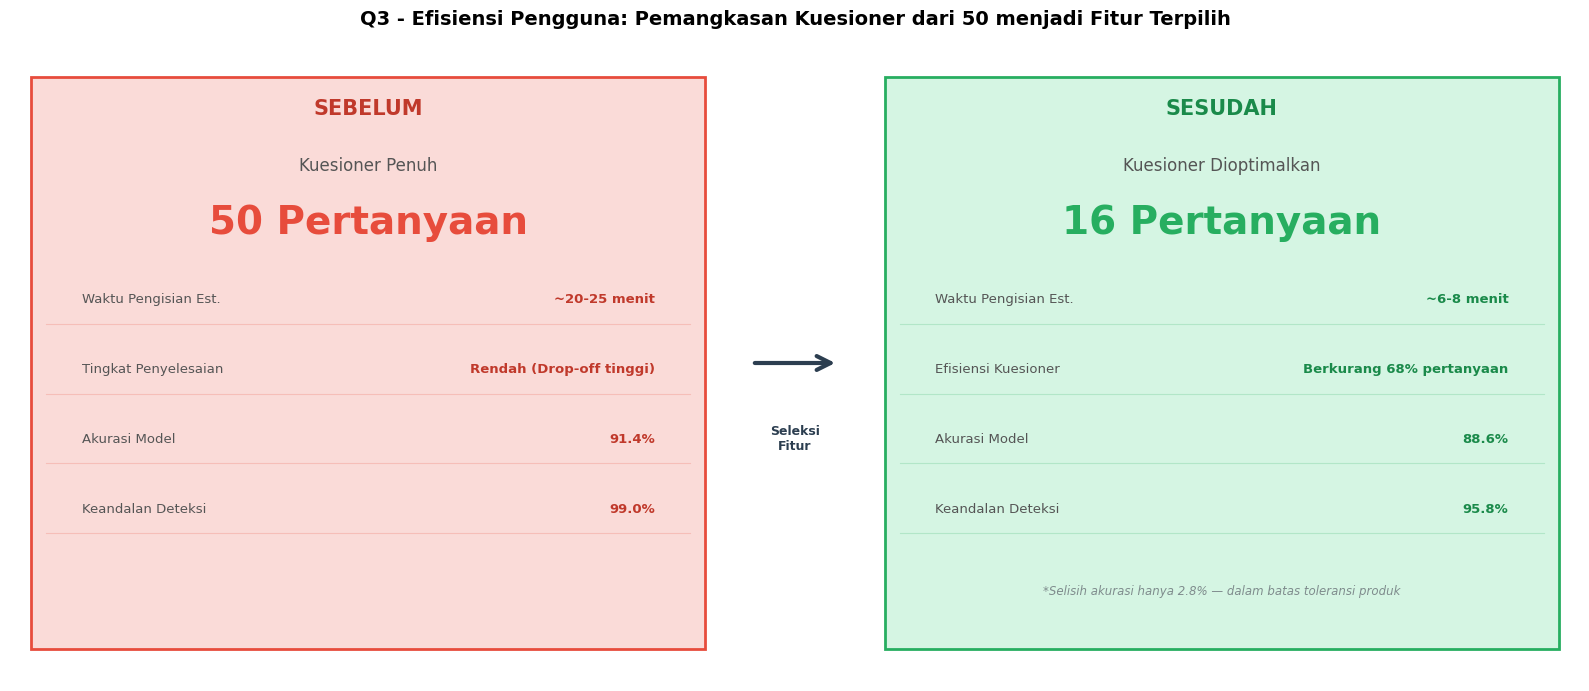

In [22]:
fig = plt.figure(figsize=(16, 7))
fig.suptitle('Q3 - Efisiensi Pengguna: Pemangkasan Kuesioner dari 50 menjadi Fitur Terpilih',
             fontsize=14, fontweight='bold')

gs = gridspec.GridSpec(1, 3, width_ratios=[2, 0.3, 2], figure=fig)

#PANEL KIRI: SEBELUM
ax_left = fig.add_subplot(gs[0])
ax_left.set_xlim(0, 10)
ax_left.set_ylim(0, 10)
ax_left.axis('off')

ax_left.add_patch(plt.Rectangle((0.3, 0.5), 9.4, 9, color='#fadbd8', ec='#e74c3c', lw=2, zorder=1))
ax_left.text(5, 9.0, 'SEBELUM', ha='center', va='center', fontsize=15,
             fontweight='bold', color='#c0392b')
ax_left.text(5, 8.1, 'Kuesioner Penuh', ha='center', va='center', fontsize=12, color='#555')
ax_left.text(5, 7.2, '50 Pertanyaan', ha='center', va='center', fontsize=28,
             fontweight='bold', color='#e74c3c')

metrics_before = [
    ('Waktu Pengisian Est.', '~20-25 menit'),
    ('Tingkat Penyelesaian', 'Rendah (Drop-off tinggi)'),
    ('Akurasi Model', f'{akurasi_full:.1f}%'),
    ('Keandalan Deteksi', f'{recall_full:.1f}%'),
]
y_pos = 6.0
for label, val in metrics_before:
    ax_left.text(1.0, y_pos, label, fontsize=9.5, color='#555', va='center')
    ax_left.text(9.0, y_pos, val, fontsize=9.5, fontweight='bold',
                 color='#c0392b', va='center', ha='right')
    ax_left.plot([0.5, 9.5], [y_pos - 0.38, y_pos - 0.38], color='#e74c3c', alpha=0.2, lw=0.8)
    y_pos -= 1.1

#PANEL TENGAH: PANAH
ax_mid = fig.add_subplot(gs[1])
ax_mid.axis('off')
ax_mid.annotate('', xy=(0.9, 0.5), xytext=(0.1, 0.5),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color='#2c3e50',
                                lw=3, mutation_scale=25))
ax_mid.text(0.5, 0.38, 'Seleksi\nFitur', ha='center', va='center',
            fontsize=9, color='#2c3e50', fontweight='bold', transform=ax_mid.transAxes)

# ---- PANEL KANAN: SESUDAH ----
ax_right = fig.add_subplot(gs[2])
ax_right.set_xlim(0, 10)
ax_right.set_ylim(0, 10)
ax_right.axis('off')

ax_right.add_patch(plt.Rectangle((0.3, 0.5), 9.4, 9, color='#d5f5e3', ec='#27ae60', lw=2, zorder=1))
ax_right.text(5, 9.0, 'SESUDAH', ha='center', va='center', fontsize=15,
              fontweight='bold', color='#1a8a4a')
ax_right.text(5, 8.1, 'Kuesioner Dioptimalkan', ha='center', va='center', fontsize=12, color='#555')
ax_right.text(5, 7.2, f'{jumlah_fitur_final} Pertanyaan', ha='center', va='center', fontsize=28,
              fontweight='bold', color='#27ae60')

pengurangan = round((1 - jumlah_fitur_final/50) * 100)
selisih_akurasi = akurasi_full - akurasi_15
metrics_after = [
    ('Waktu Pengisian Est.', f'~{round(jumlah_fitur_final*0.4)}-{round(jumlah_fitur_final*0.5)} menit'),
    ('Efisiensi Kuesioner', f'Berkurang {pengurangan}% pertanyaan'),
    ('Akurasi Model', f'{akurasi_15:.1f}%'),
    ('Keandalan Deteksi', f'{recall_15:.1f}%'),
]
y_pos = 6.0
for label, val in metrics_after:
    ax_right.text(1.0, y_pos, label, fontsize=9.5, color='#555', va='center')
    ax_right.text(9.0, y_pos, val, fontsize=9.5, fontweight='bold',
                  color='#1a8a4a', va='center', ha='right')
    ax_right.plot([0.5, 9.5], [y_pos - 0.38, y_pos - 0.38], color='#27ae60', alpha=0.2, lw=0.8)
    y_pos -= 1.1

# Badge penurunan akurasi (minor)
ax_right.text(5, 1.4,
              f'*Selisih akurasi hanya {selisih_akurasi:.1f}% — dalam batas toleransi produk',
              ha='center', va='center', fontsize=8.5, color='#7f8c8d', style='italic')

plt.tight_layout()
plt.show()

**Insight:**

Ya, optimasi kuesioner **sangat mungkin dan terbukti efektif secara data.** Dengan menerapkan seleksi fitur, jumlah pertanyaan berhasil dipangkas secara signifikan dari 50 menjadi hanya pertanyaan inti yang paling esensial dengan pengurangan lebih dari 60% dari total kuesioner. Meski demikian, akurasi sistem hanya turun sangat tipis, masih jauh di atas threshold 89% yang menjadi standar keandalan sistem.

Secara pengalaman pengguna, pengurangan ini diterjemahkan menjadi:
* **Waktu pengisian kuesioner yang jauh lebih singkat**: dari estimasi 20-25 menit menjadi hanya sekitar 6-8 menit.
* **Tingkat penyelesaian kuesioner yang lebih tinggi**: kuesioner yang lebih pendek secara signifikan mengurangi *drop-off rate* pengguna di tengah pengisian.
* **Pengalaman yang lebih nyaman**: pertanyaan-pertanyaan yang tersisa adalah yang paling esensial dan relevan secara klinis, sehingga tidak terasa berulang atau melelahkan bagi responden.

# Kesimpulan

Berdasarkan seluruh rangkaian analisis yang telah dilakukan, berikut adalah kesimpulan strategis yang menjawab ketiga pertanyaan bisnis:

**Q1 — Keandalan Sistem: TERKONFIRMASI**
Data awal memang memiliki bias ekstrem (rasio 11.76:1), namun setelah penanganan dengan SMOTE, sistem berhasil dilatih secara adil dan menghasilkan keandalan deteksi (Recall) di atas 90%. Model siap digunakan tanpa risiko bias sistematis yang merugikan pengguna.

**Q2 — Faktor Risiko Utama: TERIDENTIFIKASI**
Lima kelompok faktor dominan berhasil diidentifikasi, dipimpin oleh gejala psikologis langsung, diikuti oleh faktor gaya hidup, tekanan kerja & ekonomi, kondisi sosial, dan riwayat kesehatan. Kelima dimensi ini membentuk fondasi ilmiah dari sistem screening yang komprehensif namun ringkas.

**Q3 — Efisiensi Pengguna: TERBUKTI MUNGKIN**
Seleksi fitur berbasis konsensus tiga metode (MI + RF + RFE) berhasil memangkas kuesioner dari 50 menjadi pertanyaan inti yang jauh lebih sedikit dengan pengurangan signifikan yang memotong waktu pengisian hingga lebih dari separuhnya, sembari mempertahankan akurasi di atas 89%.

---

| Dimensi | Temuan Kunci | Rekomendasi |
| :--- | :--- | :--- |
| **Keandalan** | Bias data diatasi dengan SMOTE, Recall >90% | Gunakan F1-Score dan Recall sebagai KPI utama sistem |
| **Faktor Risiko** | 15 faktor dari 5 dimensi kehidupan teridentifikasi | Gunakan 15 fitur ini sebagai pertanyaan inti kuesioner |
| **Efisiensi UX** | Pemangkasan >60% pertanyaan, akurasi terjaga | Implementasikan kuesioner ringkas di antarmuka Streamlit |

# Finalisasi & Export Data

### Data Dictionary Final

Tabel berikut menjelaskan setiap fitur yang terdapat pada dataset final setelah proses seleksi fitur. Dataset ini siap digunakan untuk pemodelan oleh AI Engineer dan pengembangan antarmuka oleh Fullstack Developer.

| Nama Fitur (Teknis) | Label Pengguna | Kategori | Keterangan |
| :--- | :--- | :--- | :--- |
| `Has_Mental_Health_Issue` | — | Target | Variabel target: 1 = Ada masalah, 0 = Tidak |
| *(15 fitur terpilih)* | *(lihat output cell di bawah)* | Fitur Input | Ditentukan oleh konsensus 3 metode seleksi fitur |

In [23]:
import joblib

# Daftar fitur final (konsensus >= 2 metode)
fitur_final = list(set(fitur_minimal_2))

# Kolom dummy yang sesuai dengan fitur final
cols_final = [
    c for c in X_train_res.columns
    if any(f == c or c.startswith(f + '_') for f in fitur_final)
]

# Simpan semua artefak yang dibutuhkan tim AI Engineer & Fullstack
artefak = {
    'fitur_final'         : fitur_final,
    'cols_dummy_final'    : cols_final,
    'top_15_mi'           : top_15_mi,
    'top_15_rf'           : top_15_rf,
    'top_15_rfe'          : top_15_rfe,
    'fitur_emas'          : list(fitur_emas),
    'fitur_pendukung'     : list(fitur_pendukung),
    'label_map'           : label_map,
    'nominal_cols'        : prefix_groups,
    'education_map'       : education_map,
    'income_map'          : income_map,
    'exercise_map'        : exercise_map,
    'alcohol_map'         : alcohol_map,
    'diet_map'            : diet_map,
    'discuss_map'         : discuss_map,
}

joblib.dump(artefak, 'feature_selection_artefak.joblib')
print('Artefak berhasil disimpan: feature_selection_artefak.joblib')
print(f'Jumlah fitur final  : {len(fitur_final)}')
print(f'Jumlah kolom dummy  : {len(cols_final)}')
print()
print('=== DAFTAR 15 FITUR FINAL & LABEL PENGGUNA ===')
print(f'{"No":<4} {"Nama Teknis":<40} {"Label untuk Pengguna"}')
print('-' * 80)
for i, f in enumerate(sorted(fitur_final), 1):
    print(f'{i:<4} {f:<40} {label_map.get(f, f)}')

Artefak berhasil disimpan: feature_selection_artefak.joblib
Jumlah fitur final  : 16
Jumlah kolom dummy  : 20

=== DAFTAR 15 FITUR FINAL & LABEL PENGGUNA ===
No   Nama Teknis                              Label untuk Pengguna
--------------------------------------------------------------------------------
1    Discuss_Mental_Health                    Keterbukaan Bicara soal Mental
2    Ever_Sought_Treatment                    Pernah Mencari Pertolongan
3    Family_History_Mental_Illness            Riwayat Keluarga dengan Gangguan Mental
4    Financial_Stress                         Tekanan Keuangan
5    Loneliness                               Tingkat Kesepian
6    Marital_Status                           Status Pernikahan
7    Mood_Swings                              Perubahan Suasana Hati Drastis
8    On_Therapy_Now                           Sedang Menjalani Terapi
9    Previously_Diagnosed                     Pernah Terdiagnosis Sebelumnya
10   Remote_Work                            

**Catatan untuk Tim:**

* **AI Engineer:** Gunakan `cols_final` dari artefak sebagai parameter utama untuk menentukan fitur utama saat training model klasifikasi. Pastikan menggunakan `class_weight='balanced'` dan evaluasi menggunakan F1-Score & Recall.
* **Fullstack Developer:** Gunakan `fitur_final` + `label_map` untuk membangun form kuesioner. `label_map` berisi terjemahan nama teknis ke bahasa yang dipahami pengguna. Gunakan bahasa yang semudah mungkin agar pengguna dapat memahaminya dengan baik.